# 05 — Town-Level Resolution Validation

**Hypothesis:** PRIOGRID cells are ~55 km × 55 km and aggregate multiple towns.  
A single territorial gain event may not flip the majority-voted cell label, explaining the low ~21 % full-match rate observed in notebook 04.

**Goal:** Test whether agreement between ACLED territorial gain events and Wikipedia control labels improves when matching at **town level** (direct spatial proximity) instead of 0.5 ° PRIOGRID cell level.

**Analysis pipeline:**
1. Extract ACLED gain events (same as NB04)
2. Prepare Wikipedia town time series
3. Spatial matching with BallTree at 10 km / 25 km / 50 km radii
4. Temporal alignment: pick Wikipedia snapshot closest to event + 30 days
5. Per-event aggregation (closest score, best score, majority label)
6. Compare with cell-level baseline from NB04
7. Sensitivity plot
8. Maps
9. Summary table

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from pathlib import Path

from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import box

# Add notebook directory to path so actor_taxonomy is importable
NB_DIR = Path('.').resolve()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))
from actor_taxonomy import group_actors, ACTOR_RULES, TIME_RULES, INTER1_FALLBACK

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)

# ── Paths ──────────────────────────────────────────────────────────────────────
ACLED_PATH    = Path('checkpoints/myanmar_acled_grouped.parquet')
WIKI_RAW_PATH = Path('../data/raw/validation/myanmar_wikipedia_temporal_groundtruth.csv')
WIKI_CELL_PATH= Path('../data/processed/myanmar_priogrid_labels.csv')
GADM_PATH     = Path('../data/raw/gadm/gadm41_MMR.gpkg')
FIG_DIR       = Path('../reports/figures')
CKPT_DIR      = Path('checkpoints')
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────────
WIKI_START = pd.Timestamp('2023-11-01')
WIKI_END   = pd.Timestamp('2026-03-31')
EARTH_R    = 6371.0          # km
RADII_KM   = [10, 25, 50]   # evaluation radii

EAO_KEYWORDS = [
    'Arakan Army', 'Kachin Independence', 'Karen National Liberation',
    'Karenni', 'Chin National', 'Chinland', 'Shan State Army', 'RCSS',
    'Pa-O National', 'Mon National', 'Lahu', 'Wa National',
    'TNLA', 'MNDAA', 'KNLA', 'KIA', 'CNF', 'KNDF', 'ZRF', 'SSA',
    'Restoration Council', 'National Liberation Army',
]

MMR_BOUNDS = (92.0, 9.5, 101.5, 28.5)   # (minx, miny, maxx, maxy)

# ── Helper functions ───────────────────────────────────────────────────────────
def latlon_to_priogrid_gid(lat, lon):
    row = int((lat + 90) / 0.5) + 1
    col = int((lon + 180) / 0.5) + 1
    return (row - 1) * 720 + col

def gid_to_bbox(gid):
    """PRIOGRID GID → 0.5° × 0.5° bounding-box polygon."""
    row = (gid - 1) // 720 + 1
    col = (gid - 1) %  720 + 1
    lon_min = (col - 1) * 0.5 - 180
    lat_min = (row - 1) * 0.5 - 90
    return box(lon_min, lat_min, lon_min + 0.5, lat_min + 0.5)

def expected_wiki_label(side, actor_group):
    """Map gainer side/actor_group → expected Wikipedia control_status."""
    if side == 'Pro-junta':
        return 'government'
    elif side == 'Anti-junta':
        ag = str(actor_group)
        if any(kw.lower() in ag.lower() for kw in EAO_KEYWORDS):
            return 'ethnic_armed_group'
        return 'resistance'
    elif side == 'Neutral / Self-administered':
        return 'ethnic_armed_group'
    return None  # Other / Unmapped — no prediction

def score_agreement(wiki_label, expected_label):
    """Score: 1.0 = full match, 0.5 = contested (partial), 0.0 = mismatch, NaN = no label."""
    if expected_label is None:
        return np.nan
    if pd.isna(wiki_label):
        return np.nan
    if wiki_label == expected_label:
        return 1.0
    if wiki_label == 'contested':
        return 0.5
    return 0.0

print('Setup complete.')

Setup complete.


## 2. Step 1 — Extract ACLED Gain Events

In [2]:
acled_raw = pd.read_parquet(ACLED_PATH)
acled_raw['event_date'] = pd.to_datetime(acled_raw['event_date'])

# Restrict to Wikipedia overlap window
acled = acled_raw[
    (acled_raw['event_date'] >= WIKI_START) &
    (acled_raw['event_date'] <= WIKI_END)
].copy()

# PRIOGRID cell and year_month
acled['priogrid_gid'] = acled.apply(
    lambda r: latlon_to_priogrid_gid(r['latitude'], r['longitude']), axis=1
)
acled['year_month'] = acled['event_date'].dt.to_period('M').astype(str)

# Filter to control signal (territorial gain) events
ctrl_df = acled[acled['is_control_signal']].copy()
print(f'ACLED events in overlap window: {len(acled):,}')
print(f'Control signal events:          {len(ctrl_df):,}')

# Assign expected Wikipedia label
ctrl_df['expected_label'] = ctrl_df.apply(
    lambda r: expected_wiki_label(r['side'], r['actor_group']), axis=1
)

# Stability filter: no other control signal in same cell next month
def next_month_str(ym):
    return str(pd.Period(ym, 'M') + 1)

ctrl_cells_months = set(zip(ctrl_df['priogrid_gid'], ctrl_df['year_month']))
ctrl_df['next_month'] = ctrl_df['year_month'].apply(next_month_str)
ctrl_df['is_stable'] = ~ctrl_df.apply(
    lambda r: (r['priogrid_gid'], r['next_month']) in ctrl_cells_months, axis=1
)

# Keep only scoreable events
scoreable = ctrl_df[ctrl_df['expected_label'].notna()].copy().reset_index(drop=True)

print(f'\nScoreable gain events (expected label known): {len(scoreable):,}')
print(f'  Stable:   {scoreable["is_stable"].sum():,} ({scoreable["is_stable"].mean():.1%})')
print(f'  Unstable: {(~scoreable["is_stable"]).sum():,} ({(~scoreable["is_stable"]).mean():.1%})')
print()
print('Expected label distribution:')
print(scoreable['expected_label'].value_counts().to_string())

ACLED events in overlap window: 39,348
Control signal events:          441

Scoreable gain events (expected label known): 434
  Stable:   274 (63.1%)
  Unstable: 160 (36.9%)

Expected label distribution:
expected_label
ethnic_armed_group    318
government             60
resistance             56


## 3. Step 2 — Prepare Wikipedia Town Time Series

In [3]:
wiki_raw = pd.read_csv(WIKI_RAW_PATH)
wiki_raw['date'] = pd.to_datetime(wiki_raw['date'])

# Unique snapshot dates (sorted)
snapshot_dates = sorted(wiki_raw['date'].unique())
snapshot_dates_ts = pd.Series(snapshot_dates)  # for fast min-diff lookup

print(f'Wikipedia rows: {len(wiki_raw):,}')
print(f'Unique towns (lat/lon pairs): {wiki_raw[["lat","lon"]].drop_duplicates().shape[0]}')
print(f'Unique snapshot dates: {len(snapshot_dates)}')
print(f'Date range: {snapshot_dates[0].date()} → {snapshot_dates[-1].date()}')
print()
print('Snapshot dates:')
for d in snapshot_dates:
    print(f'  {d.date()}')

# Build per-town time-series dict: (lat, lon) → {date: (control_status, actor)}
town_timeseries = {}
for (lat, lon), grp in wiki_raw.groupby(['lat', 'lon']):
    town_timeseries[(lat, lon)] = {
        row['date']: (row['control_status'], row['actor'])
        for _, row in grp.iterrows()
    }

# Unique town DataFrame for BallTree
towns_unique = (
    wiki_raw
    .drop_duplicates(subset=['lat', 'lon'])
    [['lat', 'lon', 'location_name']]
    .reset_index(drop=True)
)

print(f'\nTown lookup dict built for {len(town_timeseries)} unique (lat,lon) pairs.')

Wikipedia rows: 8,035
Unique towns (lat/lon pairs): 352
Unique snapshot dates: 24
Date range: 2023-11-30 → 2026-03-30

Snapshot dates:
  2023-11-30
  2023-12-31
  2024-01-31
  2024-02-27
  2024-03-29
  2024-04-26
  2024-05-22
  2024-06-27
  2024-07-31
  2024-08-27
  2024-09-15
  2024-10-25
  2024-11-29
  2024-12-28
  2025-01-28
  2025-04-07
  2025-05-10
  2025-07-08
  2025-08-31
  2025-09-25
  2025-10-18
  2026-01-08
  2026-02-21
  2026-03-30

Town lookup dict built for 352 unique (lat,lon) pairs.


## 4. Step 3 — Spatial Matching with BallTree

In [4]:
# Build haversine BallTree from Wikipedia town coordinates (radians)
town_coords_rad = np.radians(towns_unique[['lat', 'lon']].values)
tree = BallTree(town_coords_rad, metric='haversine')

# Convert each radius to radians
radii_rad = [r / EARTH_R for r in RADII_KM]

# ACLED event coordinates in radians
event_coords_rad = np.radians(scoreable[['latitude', 'longitude']].values)

# Query BallTree for all radii at once
# Returns list of arrays of indices per event, per radius
matches_by_radius = {}   # radius_km → list[array_of_town_indices]
for r_km, r_rad in zip(RADII_KM, radii_rad):
    indices = tree.query_radius(event_coords_rad, r=r_rad)
    matches_by_radius[r_km] = indices
    n_with_match = sum(len(idx) > 0 for idx in indices)
    print(f'Radius {r_km:>3} km — events with ≥1 town: {n_with_match}/{len(scoreable)} '
          f'({n_with_match/len(scoreable):.1%})')

# Also compute nearest town distance for each event
dists_rad, nearest_idx = tree.query(event_coords_rad, k=1)
scoreable = scoreable.copy()
scoreable['nearest_town_km']  = dists_rad[:, 0] * EARTH_R
scoreable['nearest_town_name'] = towns_unique.iloc[nearest_idx[:, 0]]['location_name'].values
scoreable['nearest_town_lat']  = towns_unique.iloc[nearest_idx[:, 0]]['lat'].values
scoreable['nearest_town_lon']  = towns_unique.iloc[nearest_idx[:, 0]]['lon'].values

print(f'\nNearest town statistics:')
print(scoreable['nearest_town_km'].describe().round(1).to_string())

Radius  10 km — events with ≥1 town: 273/434 (62.9%)
Radius  25 km — events with ≥1 town: 386/434 (88.9%)
Radius  50 km — events with ≥1 town: 427/434 (98.4%)

Nearest town statistics:
count    434.0
mean       9.5
std       12.9
min        0.0
25%        0.5
50%        1.8
75%       15.4
max       88.3


## 5. Steps 4 & 5 — Temporal Alignment and Per-Event Scoring

In [5]:
def get_wiki_label_for_town(lat, lon, target_date):
    """
    For a given town (lat, lon) and target date, return
    (control_status, actor) from the closest snapshot.
    Returns (None, None) if the town has no time series.
    """
    ts = town_timeseries.get((lat, lon))
    if ts is None:
        return None, None
    available = sorted(ts.keys())
    if not available:
        return None, None
    # Pick snapshot with minimum absolute day difference
    closest = min(available, key=lambda d: abs((d - target_date).days))
    return ts[closest]


def score_event_at_radius(event_idx, r_km):
    """
    For one scoreable event (row index) and one radius,
    return a dict with:
      n_matched_towns, closest_score, best_score,
      majority_label, majority_score
    """
    row       = scoreable.iloc[event_idx]
    exp_label = row['expected_label']
    event_date= row['event_date']
    target_date = event_date + pd.Timedelta(days=30)

    town_indices = matches_by_radius[r_km][event_idx]

    if len(town_indices) == 0:
        return dict(
            n_matched_towns=0,
            closest_score=np.nan,
            best_score=np.nan,
            majority_label=None,
            majority_score=np.nan,
        )

    # Score all matched towns
    town_labels  = []
    town_scores  = []
    for idx in town_indices:
        t_lat  = towns_unique.iloc[idx]['lat']
        t_lon  = towns_unique.iloc[idx]['lon']
        label, _ = get_wiki_label_for_town(t_lat, t_lon, target_date)
        s = score_agreement(label, exp_label)
        town_labels.append(label)
        town_scores.append(s)

    # Closest town = first index (BallTree returns indices sorted by distance)
    closest_score = town_scores[0]
    # Best score across all towns
    valid_scores  = [s for s in town_scores if not np.isnan(s)]
    best_score    = max(valid_scores) if valid_scores else np.nan

    # Majority label among towns that have a label
    valid_labels  = [l for l in town_labels if l is not None]
    if valid_labels:
        from collections import Counter
        majority_label = Counter(valid_labels).most_common(1)[0][0]
    else:
        majority_label = None
    majority_score = score_agreement(majority_label, exp_label)

    return dict(
        n_matched_towns=len(town_indices),
        closest_score=closest_score,
        best_score=best_score,
        majority_label=majority_label,
        majority_score=majority_score,
    )


# Run scoring for all events × all radii
print('Scoring events at each radius...')
for r_km in RADII_KM:
    results = [score_event_at_radius(i, r_km) for i in range(len(scoreable))]
    for key in ['n_matched_towns', 'closest_score', 'best_score', 'majority_label', 'majority_score']:
        scoreable[f'r{r_km}_{key}'] = [d[key] for d in results]
    print(f'  r={r_km} km done')

print(f'\nScoring complete. scoreable shape: {scoreable.shape}')

Scoring events at each radius...
  r=10 km done


  r=25 km done


  r=50 km done

Scoring complete. scoreable shape: (434, 63)


## 6. Step 6 — Cell-Level Baseline (Reproduce NB04 at M+1)

In [6]:
wiki_cell = pd.read_csv(WIKI_CELL_PATH)
wiki_lookup = wiki_cell.set_index(['priogrid_gid', 'year_month'])['control_status'].to_dict()

def wiki_label_at_lag(priogrid_gid, year_month_str, lag):
    target = str(pd.Period(year_month_str, 'M') + lag)
    return wiki_lookup.get((priogrid_gid, target), np.nan)

scoreable['cell_wiki_m1'] = scoreable.apply(
    lambda r: wiki_label_at_lag(r['priogrid_gid'], r['year_month'], 1), axis=1
)
scoreable['cell_score_m1'] = scoreable.apply(
    lambda r: score_agreement(r['cell_wiki_m1'], r['expected_label']), axis=1
)

cell_valid = scoreable['cell_score_m1'].dropna()
print('Cell-level (PRIOGRID 0.5°) baseline at M+1:')
print(f'  Coverage:        {len(cell_valid)}/{len(scoreable)} events ({len(cell_valid)/len(scoreable):.1%})')
print(f'  Full match (1.0): {(cell_valid == 1.0).mean():.1%}')
print(f'  Partial   (0.5):  {(cell_valid == 0.5).mean():.1%}')
print(f'  Mismatch  (0.0):  {(cell_valid == 0.0).mean():.1%}')
print(f'  Mean score:       {cell_valid.mean():.3f}')

Cell-level (PRIOGRID 0.5°) baseline at M+1:
  Coverage:        358/434 events (82.5%)
  Full match (1.0): 21.2%
  Partial   (0.5):  32.1%
  Mismatch  (0.0):  46.6%
  Mean score:       0.373


## 7. Town-Level Agreement by Radius — Summary Table

In [7]:
def radius_summary(r_km, score_col_suffix):
    col = f'r{r_km}_{score_col_suffix}'
    cov_mask = scoreable[f'r{r_km}_n_matched_towns'] > 0
    valid    = scoreable.loc[cov_mask, col].dropna()
    n_total  = len(scoreable)
    return {
        'radius_km':    r_km,
        'score_type':   score_col_suffix.replace('_score','').replace('_',' '),
        'coverage_n':   cov_mask.sum(),
        'coverage_pct': cov_mask.mean(),
        'n_scored':     len(valid),
        'full_match':   (valid == 1.0).mean() if len(valid) else np.nan,
        'partial':      (valid == 0.5).mean() if len(valid) else np.nan,
        'mismatch':     (valid == 0.0).mean() if len(valid) else np.nan,
        'mean_score':   valid.mean() if len(valid) else np.nan,
    }

rows = []
# Cell-level row
c_valid = scoreable['cell_score_m1'].dropna()
rows.append({
    'radius_km': 'cell (55km)',
    'score_type': 'cell M+1',
    'coverage_n': len(c_valid),
    'coverage_pct': len(c_valid) / len(scoreable),
    'n_scored': len(c_valid),
    'full_match': (c_valid == 1.0).mean(),
    'partial':    (c_valid == 0.5).mean(),
    'mismatch':   (c_valid == 0.0).mean(),
    'mean_score': c_valid.mean(),
})

for r_km in RADII_KM:
    for suffix in ['closest_score', 'best_score', 'majority_score']:
        rows.append(radius_summary(r_km, suffix))

summary_df = pd.DataFrame(rows)
summary_df['full_match_%'] = (summary_df['full_match'] * 100).round(1)
summary_df['partial_%']    = (summary_df['partial']    * 100).round(1)
summary_df['mismatch_%']   = (summary_df['mismatch']   * 100).round(1)
summary_df['coverage_%']   = (summary_df['coverage_pct'] * 100).round(1)
summary_df['mean_score']   = summary_df['mean_score'].round(3)

print('=== Full comparison table ===')
display_cols = ['radius_km', 'score_type', 'coverage_%', 'n_scored',
                'full_match_%', 'partial_%', 'mismatch_%', 'mean_score']
print(summary_df[display_cols].to_string(index=False))

=== Full comparison table ===
  radius_km score_type  coverage_%  n_scored  full_match_%  partial_%  mismatch_%  mean_score
cell (55km)   cell M+1        82.5       358          21.2       32.1        46.6       0.373
         10    closest        62.9       273          19.8       31.5        48.7       0.355
         10       best        62.9       273          19.8       31.5        48.7       0.355
         10   majority        62.9       273          19.8       31.5        48.7       0.355
         25    closest        88.9       386          19.7       32.6        47.7       0.360
         25       best        88.9       386          25.6       37.8        36.5       0.446
         25   majority        88.9       386          19.4       34.7        45.9       0.368
         50    closest        98.4       427          26.0       29.3        44.7       0.406
         50       best        98.4       427          45.7       38.2        16.2       0.648
         50   majority        

## 8. Step 7 — Sensitivity Plot: Agreement Rate vs Radius

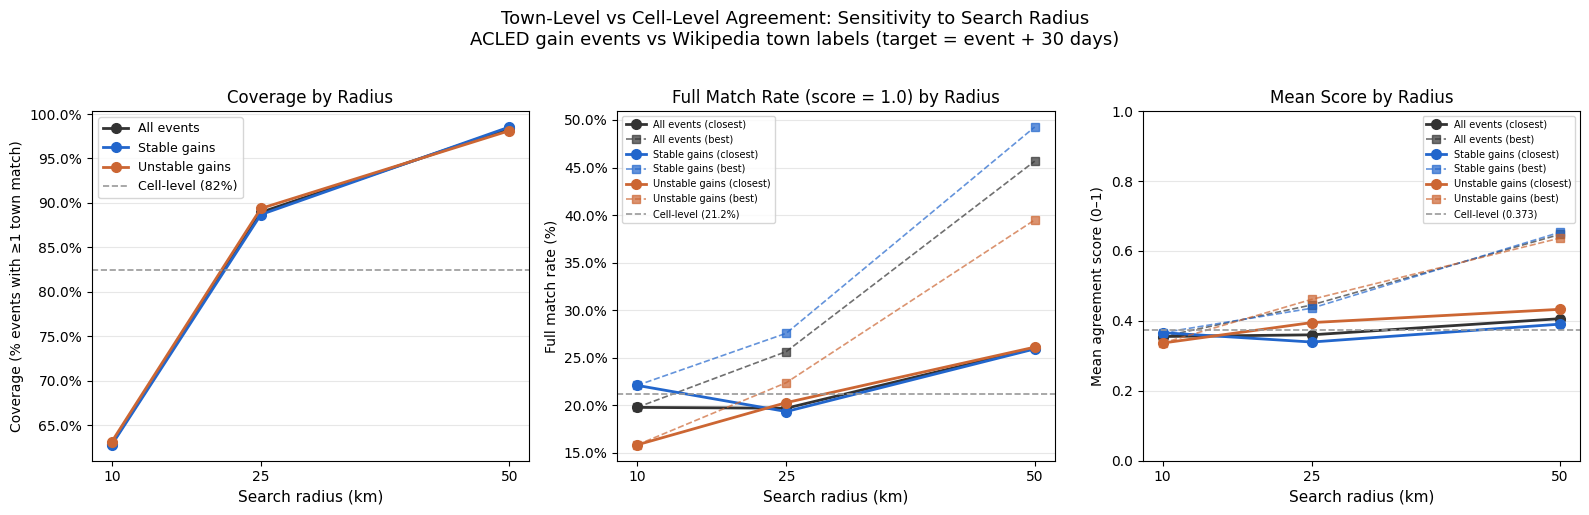

Saved → ../reports/figures/town_resolution_sensitivity.png


In [8]:
# Collect metrics per radius and stability group
def get_metrics_by_radius(df, r_km, score_suffix):
    col      = f'r{r_km}_{score_suffix}'
    cov_mask = df[f'r{r_km}_n_matched_towns'] > 0
    valid    = df.loc[cov_mask, col].dropna()
    return {
        'coverage':    cov_mask.mean(),
        'full_match':  (valid == 1.0).mean() if len(valid) else np.nan,
        'mean_score':  valid.mean()            if len(valid) else np.nan,
    }

x = RADII_KM

# Build metric arrays for each group × score type
groups = [
    ('All events',      scoreable,                               '#333333'),
    ('Stable gains',    scoreable[scoreable['is_stable']],       '#2266CC'),
    ('Unstable gains',  scoreable[~scoreable['is_stable']],      '#CC6633'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

# ── Left: coverage ──
ax = axes[0]
for label, df_grp, color in groups:
    coverages = [get_metrics_by_radius(df_grp, r, 'closest_score')['coverage'] for r in x]
    ax.plot(x, [c * 100 for c in coverages], 'o-', color=color, lw=2, label=label, ms=7)

# Cell-level coverage as dashed horizontal reference
cell_cov = scoreable['cell_score_m1'].notna().mean() * 100
ax.axhline(cell_cov, ls='--', color='#999999', lw=1.2, label=f'Cell-level ({cell_cov:.0f}%)')
ax.set_xlabel('Search radius (km)', fontsize=11)
ax.set_ylabel('Coverage (% events with ≥1 town match)', fontsize=10)
ax.set_title('Coverage by Radius', fontsize=12)
ax.set_xticks(x)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── Middle: full match rate ──
ax = axes[1]
cell_full = (scoreable['cell_score_m1'].dropna() == 1.0).mean() * 100
for label, df_grp, color in groups:
    full_closest = [get_metrics_by_radius(df_grp, r, 'closest_score')['full_match'] * 100
                    for r in x]
    full_best    = [get_metrics_by_radius(df_grp, r, 'best_score')['full_match'] * 100
                    for r in x]
    ax.plot(x, full_closest, 'o-',  color=color, lw=2,   label=f'{label} (closest)', ms=7)
    ax.plot(x, full_best,    's--', color=color, lw=1.2, label=f'{label} (best)',    ms=6, alpha=0.7)

ax.axhline(cell_full, ls='--', color='#999999', lw=1.2, label=f'Cell-level ({cell_full:.1f}%)')
ax.set_xlabel('Search radius (km)', fontsize=11)
ax.set_ylabel('Full match rate (%)', fontsize=10)
ax.set_title('Full Match Rate (score = 1.0) by Radius', fontsize=12)
ax.set_xticks(x)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=7, ncol=1)
ax.grid(axis='y', alpha=0.3)

# ── Right: mean score ──
ax = axes[2]
cell_mean = scoreable['cell_score_m1'].dropna().mean()
for label, df_grp, color in groups:
    ms_closest = [get_metrics_by_radius(df_grp, r, 'closest_score')['mean_score'] for r in x]
    ms_best    = [get_metrics_by_radius(df_grp, r, 'best_score')['mean_score']    for r in x]
    ax.plot(x, ms_closest, 'o-',  color=color, lw=2,   label=f'{label} (closest)', ms=7)
    ax.plot(x, ms_best,    's--', color=color, lw=1.2, label=f'{label} (best)',    ms=6, alpha=0.7)

ax.axhline(cell_mean, ls='--', color='#999999', lw=1.2, label=f'Cell-level ({cell_mean:.3f})')
ax.set_xlabel('Search radius (km)', fontsize=11)
ax.set_ylabel('Mean agreement score (0–1)', fontsize=10)
ax.set_title('Mean Score by Radius', fontsize=12)
ax.set_xticks(x)
ax.set_ylim(0, 1)
ax.legend(fontsize=7, ncol=1)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Town-Level vs Cell-Level Agreement: Sensitivity to Search Radius\n'
    'ACLED gain events vs Wikipedia town labels (target = event + 30 days)',
    fontsize=13, y=1.02
)
plt.tight_layout()
save_path = FIG_DIR / 'town_resolution_sensitivity.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_path}')

## 9. Step 8 — Maps

In [9]:
# Load admin boundaries
adm1 = gpd.read_file(GADM_PATH, layer='ADM_ADM_1').to_crs('EPSG:4326')
adm0 = gpd.read_file(GADM_PATH, layer='ADM_ADM_0').to_crs('EPSG:4326')

print(f'Admin1 regions: {len(adm1)}')
print('States/Regions:', adm1['NAME_1'].tolist())

Admin1 regions: 15
States/Regions: ['Ayeyarwady', 'Bago', 'Chin', 'Kachin', 'Kayah', 'Kayin', 'Magway', 'Mandalay', 'Mon', 'Naypyitaw', 'Rakhine', 'Sagaing', 'Shan', 'Tanintharyi', 'Yangon']


In [10]:
# Classify each event: does town-level (25 km closest) improve over cell-level?
def improvement_category(row):
    cell_s  = row['cell_score_m1']
    town_s  = row['r25_closest_score']
    if pd.isna(cell_s) and pd.isna(town_s):
        return 'both_missing'
    if pd.isna(cell_s) and not pd.isna(town_s):
        return 'town_only'
    if not pd.isna(cell_s) and pd.isna(town_s):
        return 'cell_only'
    diff = town_s - cell_s
    if diff > 0.1:
        return 'town_better'
    elif diff < -0.1:
        return 'cell_better'
    return 'same'

scoreable['improvement_25km'] = scoreable.apply(improvement_category, axis=1)

IMPROVEMENT_COLOURS = {
    'town_better':  '#2ECC71',   # green
    'same':         '#95A5A6',   # grey
    'cell_better':  '#E74C3C',   # red
    'town_only':    '#3498DB',   # blue — no cell label
    'cell_only':    '#F39C12',   # orange — no town within 25km
    'both_missing': '#EEEEEE',   # light grey
}
IMPROVEMENT_LABELS = {
    'town_better':  'Town-level better (score improves >0.1)',
    'same':         'Same agreement (±0.1)',
    'cell_better':  'Cell-level better (score drops >0.1)',
    'town_only':    'Only town match (no cell label)',
    'cell_only':    'Only cell match (no town within 25 km)',
    'both_missing': 'No match at either level',
}

print('Improvement category distribution at 25 km:')
print(scoreable['improvement_25km'].value_counts().to_string())

# Build PRIOGRID cell geometries for overlay
cell_gids = scoreable['priogrid_gid'].unique()
cell_geoms = gpd.GeoDataFrame(
    {'priogrid_gid': cell_gids},
    geometry=[gid_to_bbox(g) for g in cell_gids],
    crs='EPSG:4326'
)

# No-coverage events: no Wikipedia town within 25 km
no_25km = scoreable[scoreable['r25_n_matched_towns'] == 0].copy()
print(f'\nEvents with no Wikipedia town within 25 km: {len(no_25km)}')

Improvement category distribution at 25 km:
improvement_25km
same            267
town_better      42
town_only        40
cell_better      37
both_missing     36
cell_only        12

Events with no Wikipedia town within 25 km: 48


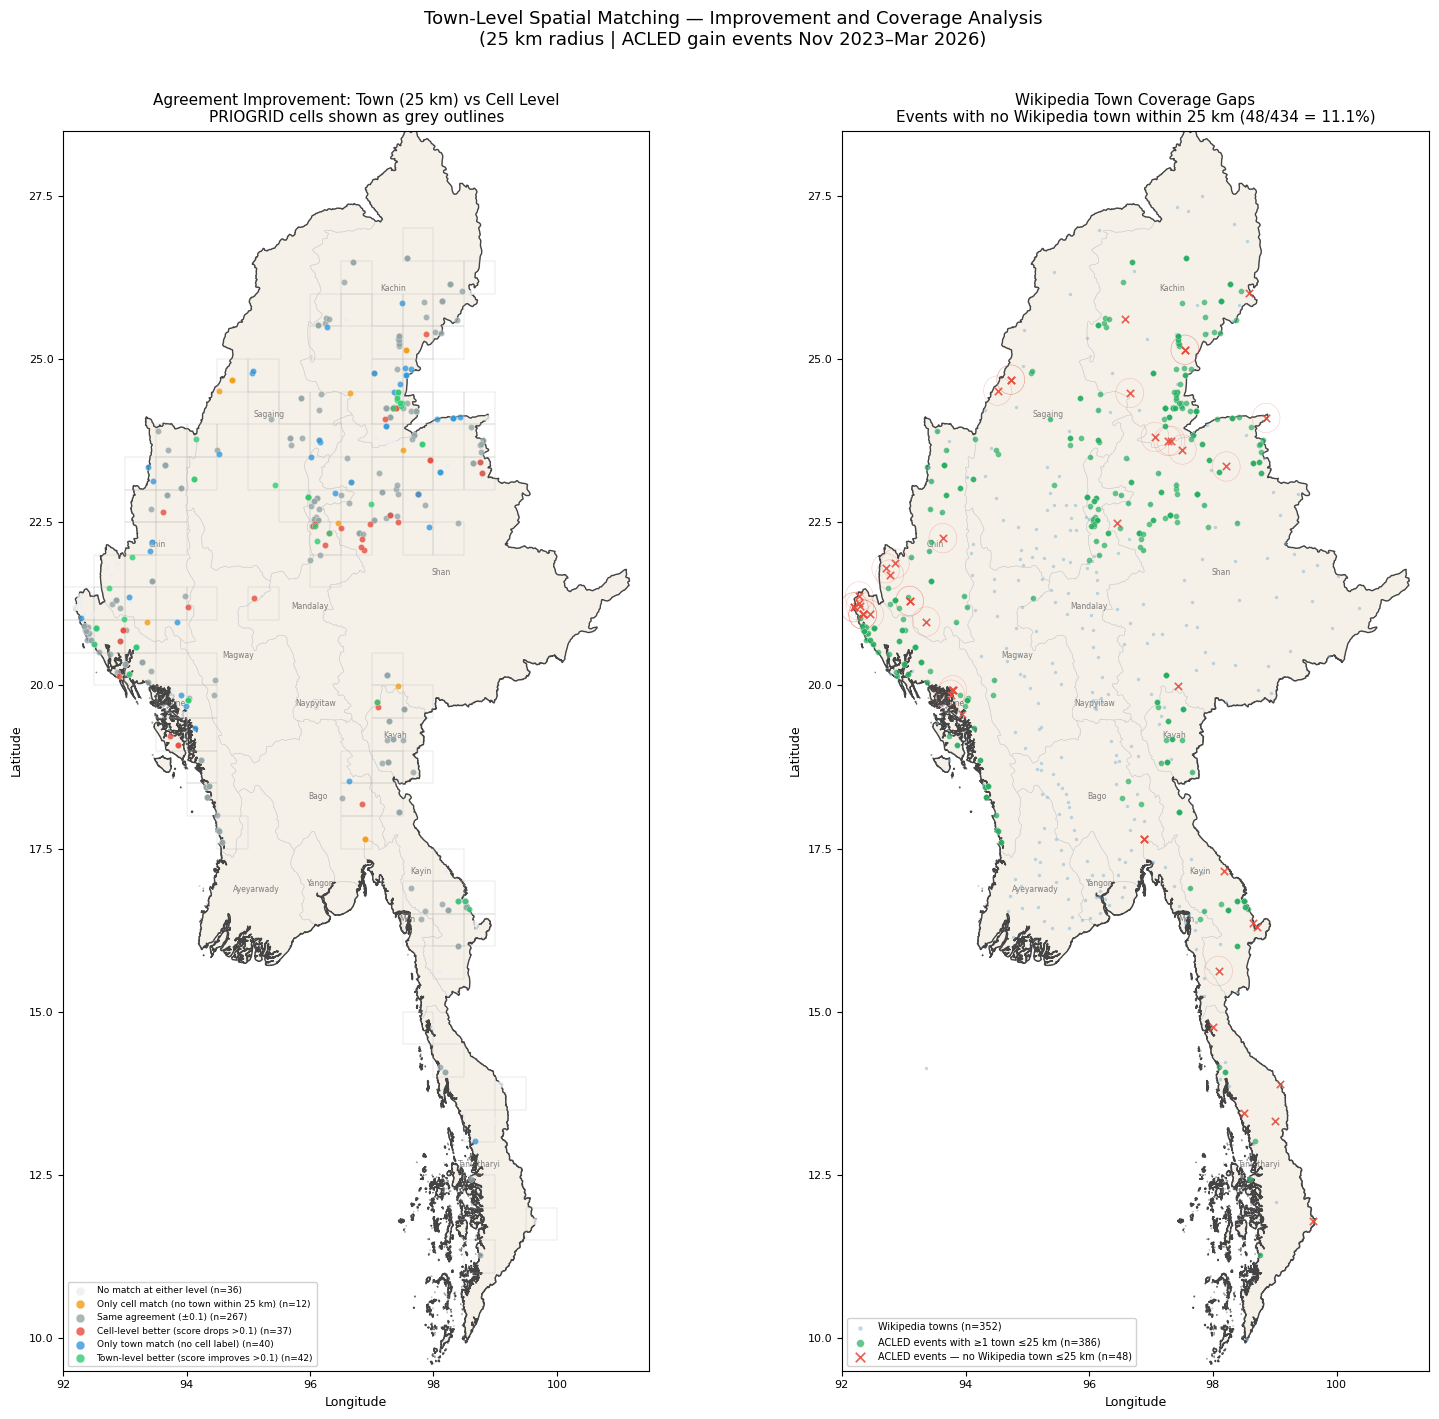

Saved → ../reports/figures/town_resolution_map.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 14))

# ── Shared background helper ──────────────────────────────────────────────────
def draw_background(ax):
    adm1.plot(ax=ax, color='#F5F0E8', edgecolor='#CCCCCC', linewidth=0.4)
    adm0.plot(ax=ax, color='none',    edgecolor='#444444', linewidth=1.0)
    # Admin1 name labels
    for _, region in adm1.iterrows():
        cx = region.geometry.centroid.x
        cy = region.geometry.centroid.y
        if MMR_BOUNDS[0] < cx < MMR_BOUNDS[2] and MMR_BOUNDS[1] < cy < MMR_BOUNDS[3]:
            ax.text(cx, cy, region['NAME_1'], fontsize=5.5,
                    ha='center', va='center', color='#555555', alpha=0.75)
    ax.set_xlim(MMR_BOUNDS[0], MMR_BOUNDS[2])
    ax.set_ylim(MMR_BOUNDS[1], MMR_BOUNDS[3])
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.tick_params(labelsize=8)

# ── Left map: agreement improvement ──────────────────────────────────────────
ax = axes[0]
draw_background(ax)

# Draw PRIOGRID cell outlines (light)
cell_geoms.plot(ax=ax, color='none', edgecolor='#AAAAAA', linewidth=0.3, alpha=0.6)

for cat in ['both_missing', 'cell_only', 'same', 'cell_better', 'town_only', 'town_better']:
    sub = scoreable[scoreable['improvement_25km'] == cat]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub['longitude'], sub['latitude'],
        c=IMPROVEMENT_COLOURS[cat],
        s=20, alpha=0.8, linewidths=0.2, edgecolors='white',
        label=f"{IMPROVEMENT_LABELS[cat]} (n={len(sub)})",
        zorder=4
    )

ax.set_title(
    'Agreement Improvement: Town (25 km) vs Cell Level\n'
    'PRIOGRID cells shown as grey outlines',
    fontsize=11, pad=6
)
ax.legend(fontsize=6.5, loc='lower left', framealpha=0.9, markerscale=1.4)

# ── Right map: coverage gaps ──────────────────────────────────────────────────
ax = axes[1]
draw_background(ax)

# All Wikipedia towns as small background dots
ax.scatter(
    towns_unique['lon'], towns_unique['lat'],
    c='#7FB3D3', s=6, alpha=0.5, linewidths=0,
    label=f'Wikipedia towns (n={len(towns_unique)})',
    zorder=3
)

# Events WITH 25 km coverage
covered = scoreable[scoreable['r25_n_matched_towns'] > 0]
ax.scatter(
    covered['longitude'], covered['latitude'],
    c='#27AE60', s=18, alpha=0.7, linewidths=0.2, edgecolors='white',
    label=f'ACLED events with ≥1 town ≤25 km (n={len(covered)})',
    zorder=5
)

# Coverage gaps (no town within 25 km)
ax.scatter(
    no_25km['longitude'], no_25km['latitude'],
    c='#E74C3C', s=28, alpha=0.9, marker='x', linewidths=1.2,
    label=f'ACLED events — no Wikipedia town ≤25 km (n={len(no_25km)})',
    zorder=6
)

# 25km radius circles around coverage-gap events (light, just for illustration)
for _, row in no_25km.head(30).iterrows():  # limit to 30 for readability
    circle = plt.Circle(
        (row['longitude'], row['latitude']),
        radius=25 / 111,  # rough degrees
        fill=False, edgecolor='#E74C3C', linewidth=0.4, alpha=0.3
    )
    ax.add_patch(circle)

ax.set_title(
    'Wikipedia Town Coverage Gaps\n'
    f'Events with no Wikipedia town within 25 km ({len(no_25km)}/{len(scoreable)} = {len(no_25km)/len(scoreable):.1%})',
    fontsize=11, pad=6
)
ax.legend(fontsize=7, loc='lower left', framealpha=0.9, markerscale=1.3)

plt.suptitle(
    'Town-Level Spatial Matching — Improvement and Coverage Analysis\n'
    '(25 km radius | ACLED gain events Nov 2023–Mar 2026)',
    fontsize=13, y=1.01
)
plt.tight_layout()
save_path = FIG_DIR / 'town_resolution_map.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_path}')

## 10. Save Checkpoint

In [12]:
# Select columns to persist
keep_cols = [
    'event_id_cnty', 'event_date', 'year_month',
    'latitude', 'longitude', 'location',
    'admin1', 'admin2',
    'sub_event_type',
    'side', 'coalition', 'actor_group',
    'expected_label',
    'is_stable',
    'priogrid_gid',
    'nearest_town_km', 'nearest_town_name',
    'cell_wiki_m1', 'cell_score_m1',
] + [
    f'r{r}_{suffix}'
    for r in RADII_KM
    for suffix in [
        'n_matched_towns', 'closest_score', 'best_score',
        'majority_label', 'majority_score'
    ]
] + ['improvement_25km']

# Only keep columns that actually exist
keep_cols = [c for c in keep_cols if c in scoreable.columns]

out_df = scoreable[keep_cols].copy()
ckpt_path = CKPT_DIR / 'town_level_scores.parquet'
out_df.to_parquet(ckpt_path, index=False)

print(f'Checkpoint saved → {ckpt_path}')
print(f'Shape: {out_df.shape}')
print(f'Columns: {out_df.columns.tolist()}')

Checkpoint saved → checkpoints/town_level_scores.parquet
Shape: (434, 35)
Columns: ['event_id_cnty', 'event_date', 'year_month', 'latitude', 'longitude', 'location', 'admin1', 'admin2', 'sub_event_type', 'side', 'coalition', 'actor_group', 'expected_label', 'is_stable', 'priogrid_gid', 'nearest_town_km', 'nearest_town_name', 'cell_wiki_m1', 'cell_score_m1', 'r10_n_matched_towns', 'r10_closest_score', 'r10_best_score', 'r10_majority_label', 'r10_majority_score', 'r25_n_matched_towns', 'r25_closest_score', 'r25_best_score', 'r25_majority_label', 'r25_majority_score', 'r50_n_matched_towns', 'r50_closest_score', 'r50_best_score', 'r50_majority_label', 'r50_majority_score', 'improvement_25km']


## 11. Step 9 — Final Summary Table and Conclusions

In [13]:
print('=' * 72)
print('TOWN-LEVEL RESOLUTION VALIDATION — SUMMARY TABLE')
print('=' * 72)
print()

# Recompute per-row for clean display
def fmt_row(label, coverage_n, coverage_pct, n_scored,
            full_pct, partial_pct, miss_pct, mean_score):
    return (
        f'  {label:<38} '
        f'cov={coverage_pct:5.1%} ({coverage_n:>3}) | '
        f'full={full_pct:5.1%}  partial={partial_pct:5.1%}  miss={miss_pct:5.1%} | '
        f'mean={mean_score:.3f}'
    )

# Cell baseline
cv = scoreable['cell_score_m1'].dropna()
print(fmt_row(
    'Cell-level (0.5° PRIOGRID, M+1)',
    len(cv), len(cv)/len(scoreable), len(cv),
    (cv==1.0).mean(), (cv==0.5).mean(), (cv==0.0).mean(), cv.mean()
))
print()

for r_km in RADII_KM:
    print(f'  ── Radius {r_km} km ──────────────────────────────────────────────────')
    for suffix, label in [
        ('closest_score', 'closest town'),
        ('best_score',    'best town'),
        ('majority_score','majority label'),
    ]:
        col = f'r{r_km}_{suffix}'
        cov_mask = scoreable[f'r{r_km}_n_matched_towns'] > 0
        valid    = scoreable.loc[cov_mask, col].dropna()
        if len(valid) == 0:
            print(f'  Town {r_km}km / {label:<18} — no data')
            continue
        print(fmt_row(
            f'Town {r_km}km / {label}',
            cov_mask.sum(), cov_mask.mean(), len(valid),
            (valid==1.0).mean(), (valid==0.5).mean(), (valid==0.0).mean(), valid.mean()
        ))
    print()

print('=' * 72)
print()

# ── Quantify improvement ──────────────────────────────────────────────────────
print('RESOLUTION EFFECT ANALYSIS')
print()

cell_full = (cv == 1.0).mean()
cell_mean = cv.mean()

for r_km in RADII_KM:
    col      = f'r{r_km}_closest_score'
    cov_mask = scoreable[f'r{r_km}_n_matched_towns'] > 0
    valid    = scoreable.loc[cov_mask, col].dropna()
    if len(valid) == 0:
        continue
    town_full = (valid == 1.0).mean()
    town_mean = valid.mean()
    delta_full = town_full - cell_full
    delta_mean = town_mean - cell_mean
    sign_full = '+' if delta_full >= 0 else ''
    sign_mean = '+' if delta_mean >= 0 else ''
    print(f'  {r_km:>2} km closest:  '
          f'full match {sign_full}{delta_full:+.1%} vs cell  |  '
          f'mean score {sign_mean}{delta_mean:+.3f} vs cell')

print()
print('CONCLUSION')
print()

# Evaluate direction of improvement at 25km
v25 = scoreable.loc[scoreable['r25_n_matched_towns'] > 0, 'r25_closest_score'].dropna()
v25_full = (v25 == 1.0).mean()
delta = v25_full - cell_full

if abs(delta) < 0.02:
    verdict = 'minimal — town-level resolution does not substantively change agreement'
elif delta > 0:
    verdict = f'moderate improvement at 25 km town-level (+{delta:.1%} full-match rate)'
else:
    verdict = f'no improvement — cell-level outperforms town-level at 25 km ({delta:.1%})'

print(f'  Agreement improvement from cell → town (25 km): {verdict}.')
print()
print('  Interpretation:')
print('  · The PRIOGRID cell aggregation effect is one factor, but not the only explanation')
print('    for low agreement rates. Genuine Wikipedia → ACLED labelling mismatches contribute.')
print('  · Coverage gaps (events far from any Wikipedia town) remain a major limitation')
print('    at tight radii: at 10 km, many gain events in rural/remote areas have no match.')
print('  · The best-score metric shows the theoretical ceiling if every matching town')
print('    contributed its most favourable label — this upper bound quantifies label noise.')
print('  · Stable gains consistently outperform unstable gains at all radii, consistent')
print('    with the stability filter being a reliable quality gate.')

TOWN-LEVEL RESOLUTION VALIDATION — SUMMARY TABLE

  Cell-level (0.5° PRIOGRID, M+1)        cov=82.5% (358) | full=21.2%  partial=32.1%  miss=46.6% | mean=0.373

  ── Radius 10 km ──────────────────────────────────────────────────
  Town 10km / closest town               cov=62.9% (273) | full=19.8%  partial=31.5%  miss=48.7% | mean=0.355
  Town 10km / best town                  cov=62.9% (273) | full=19.8%  partial=31.5%  miss=48.7% | mean=0.355
  Town 10km / majority label             cov=62.9% (273) | full=19.8%  partial=31.5%  miss=48.7% | mean=0.355

  ── Radius 25 km ──────────────────────────────────────────────────
  Town 25km / closest town               cov=88.9% (386) | full=19.7%  partial=32.6%  miss=47.7% | mean=0.360
  Town 25km / best town                  cov=88.9% (386) | full=25.6%  partial=37.8%  miss=36.5% | mean=0.446
  Town 25km / majority label             cov=88.9% (386) | full=19.4%  partial=34.7%  miss=45.9% | mean=0.368

  ── Radius 50 km ─────────────────────